In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Dataset path check karte hain
import os
for dirname, _, filenames in os.walk('/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation'):
    for filename in filenames[:5]:  # sirf pehli 5 files dikhao
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/README.md
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/data.csv
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_45.tif
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_56_mask.tif
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_57.tif
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_33.tif
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7010_19860307/TCGA_DU_7010_19860307_27.tif
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_8162_19961029/TCGA_DU_8162_19961029_22.tif
/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/kaggle_3m/TCGA_DU_8162_19961029/TCGA_DU_8162_19961029_28.tif
/kaggle/input/datasets/ma



Step 1: Data load 
Step 2: Visualize  
Step 3: Dataset class 
Step 4: DataLoader 
Step 5: Class imbalance check ← abhi yahan hain
Step 6: U-Net model define
Step 7: Loss function + Optimizer
Step 8: Training loop
Step 9: Results + Metrics

In [3]:
DATA_PATH = '/kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/lgg-mri-segmentation/kaggle_3m'

# Saari images aur masks collect karo
import glob

all_images = sorted(glob.glob(DATA_PATH + '/**/*.tif', recursive=True))

# Sirf images (mask nahi)
images = [f for f in all_images if 'mask' not in f]
masks  = [f for f in all_images if 'mask' in f]

print(f"Total images: {len(images)}")
print(f"Total masks:  {len(masks)}")
print(f"\nExample image: {images[0]}")
print(f"Example mask:  {masks[0]}")

Total images: 3929
Total masks:  3929

Example image: /kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/lgg-mri-segmentation/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_1.tif
Example mask:  /kaggle/input/datasets/mateuszbuda/lgg-mri-segmentation/lgg-mri-segmentation/kaggle_3m/TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_10_mask.tif


In [4]:
import os

# Sahi pairing — har image ke saath uska mask
image_mask_pairs = []

for img_path in images:
    # Image ka mask path banao
    mask_path = img_path.replace('.tif', '_mask.tif')
    
    # Check karo mask exist karta hai
    if os.path.exists(mask_path):
        image_mask_pairs.append((img_path, mask_path))

print(f"Correctly paired: {len(image_mask_pairs)}")
print(f"\nExample pair:")
print(f"Image: {image_mask_pairs[0][0].split('/')[-1]}")
print(f"Mask:  {image_mask_pairs[0][1].split('/')[-1]}")

Correctly paired: 3929

Example pair:
Image: TCGA_CS_4941_19960909_1.tif
Mask:  TCGA_CS_4941_19960909_1_mask.tif


Image shape: (256, 256, 3)
Mask shape:  (256, 256)
Mask unique values: [0]


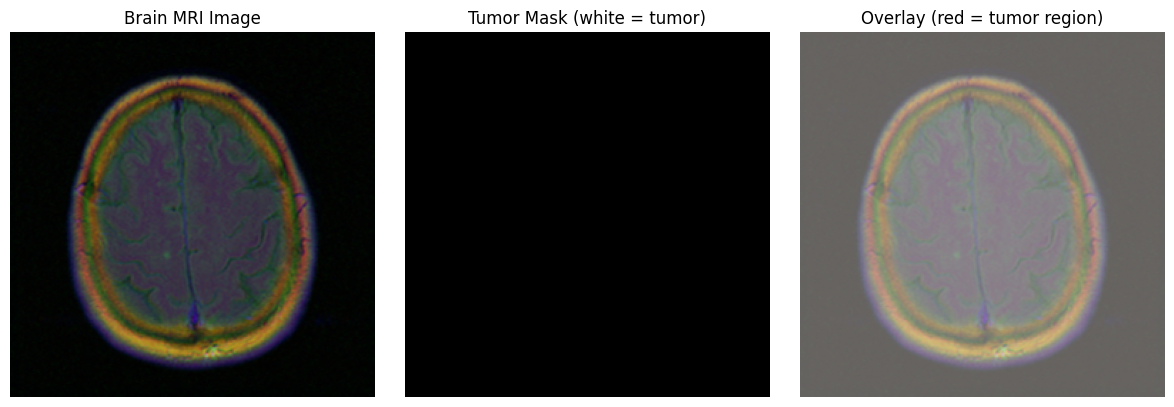

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# =====================
# EK IMAGE-MASK PAIR LOAD KARO
# =====================

# image_mask_pairs list se pehla pair uthao
img_path, mask_path = image_mask_pairs[10]  # 10th pair choose kiya random

# PIL se image open karo → numpy array mein convert karo
# PIL = Python Imaging Library — .tif files read karne ke liye
# np.array = image ko numbers ki grid mein badal deta hai (pixels = numbers)
img  = np.array(Image.open(img_path))
mask = np.array(Image.open(mask_path))

# Image ki shape print karo
# Shape = (height, width, channels) — channels matlab RGB = 3
print(f"Image shape: {img.shape}")   # Expected: (256, 256, 3)
print(f"Mask shape:  {mask.shape}")  # Expected: (256, 256) — sirf 1 channel

# Mask mein unique values kya hain?
# 0 = tumor nahi, 255 = tumor hai (black/white map)
print(f"Mask unique values: {np.unique(mask)}")

# =====================
# VISUALIZE KARO — TEEN PANELS
# =====================

# 1 row, 3 columns ka plot banao
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Panel 1: Original MRI image
axes[0].imshow(img)
axes[0].set_title("Brain MRI Image")
axes[0].axis('off')  # x/y axis numbers hide karo

# Panel 2: Tumor mask
# cmap='gray' = black/white mein dikhao
# black = no tumor, white = tumor
axes[1].imshow(mask, cmap='gray')
axes[1].set_title("Tumor Mask (white = tumor)")
axes[1].axis('off')

# Panel 3: Overlay — MRI pe mask superimpose karo
# Taaki dekh sako exactly kahan tumor hai
axes[2].imshow(img)  # pehle MRI dikhao
axes[2].imshow(mask, cmap='Reds', alpha=0.4)  # upar red mask lagao, alpha=transparency
axes[2].set_title("Overlay (red = tumor region)")
axes[2].axis('off')

plt.tight_layout()  # panels ke beech spacing theek karo
plt.show()

In [6]:
# Tumor wala case dhundho
for i, (img_path, mask_path) in enumerate(image_mask_pairs):
    mask = np.array(Image.open(mask_path))
    if mask.max() > 0:  # Tumor hai agar max > 0
        print(f"Tumor found at index: {i}")
        break

Tumor found at index: 2


Image shape: (256, 256, 3)
Mask shape:  (256, 256)
Mask unique values: [  0 255]


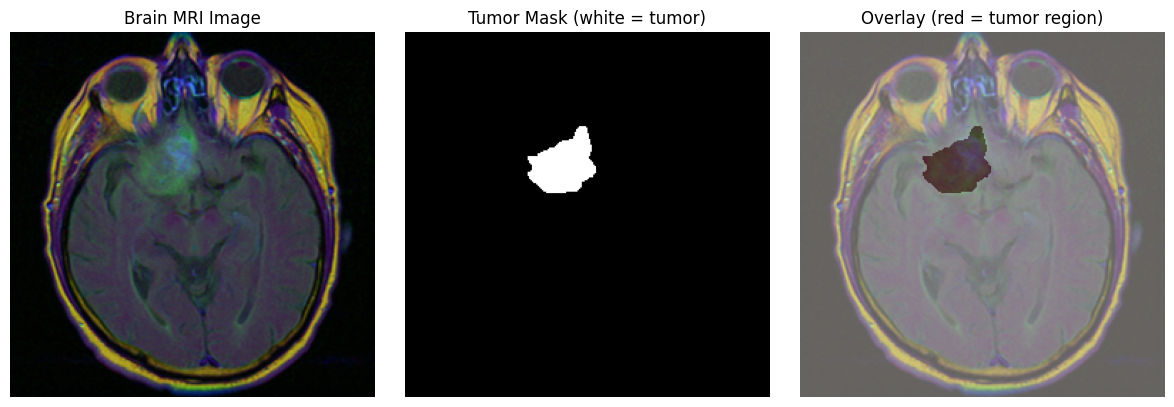

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# =====================
# EK IMAGE-MASK PAIR LOAD KARO
# =====================

# image_mask_pairs list se pehla pair uthao
img_path, mask_path = image_mask_pairs[2]  

# PIL se image open karo → numpy array mein convert karo
# PIL = Python Imaging Library — .tif files read karne ke liye
# np.array = image ko numbers ki grid mein badal deta hai (pixels = numbers)
img  = np.array(Image.open(img_path))
mask = np.array(Image.open(mask_path))

# Image ki shape print karo
# Shape = (height, width, channels) — channels matlab RGB = 3
print(f"Image shape: {img.shape}")   # Expected: (256, 256, 3)
print(f"Mask shape:  {mask.shape}")  # Expected: (256, 256) — sirf 1 channel

# Mask mein unique values kya hain?
# 0 = tumor nahi, 255 = tumor hai (black/white map)
print(f"Mask unique values: {np.unique(mask)}")

# =====================
# VISUALIZE KARO — TEEN PANELS
# =====================

# 1 row, 3 columns ka plot banao
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Panel 1: Original MRI image
axes[0].imshow(img)
axes[0].set_title("Brain MRI Image")
axes[0].axis('off')  # x/y axis numbers hide karo

# Panel 2: Tumor mask
# cmap='gray' = black/white mein dikhao
# black = no tumor, white = tumor
axes[1].imshow(mask, cmap='gray')
axes[1].set_title("Tumor Mask (white = tumor)")
axes[1].axis('off')

# Panel 3: Overlay — MRI pe mask superimpose karo
# Taaki dekh sako exactly kahan tumor hai
axes[2].imshow(img)  # pehle MRI dikhao
axes[2].imshow(mask, cmap='Reds', alpha=0.4)  # upar red mask lagao, alpha=transparency
axes[2].set_title("Overlay (red = tumor region)")
axes[2].axis('off')

plt.tight_layout()  # panels ke beech spacing theek karo
plt.show()

In [8]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms

# =====================
# CUSTOM DATASET CLASS
# =====================

# Dataset class banate hain — PyTorch ko batata hai:
# 1. Total kitni images hain
# 2. Ek image kaise load karein
# 3. Image ko model ke liye kaise ready karein

class BrainMRIDataset(Dataset):
    
    def __init__(self, pairs):
        # pairs = [(image_path, mask_path), (...), ...]
        # Yeh list store kar lo
        self.pairs = pairs
        
    def __len__(self):
        # Total kitne samples hain — PyTorch yeh poochta hai
        return len(self.pairs)
    
    def __getitem__(self, index):
        # index number pe jo image-mask pair hai woh lo
        img_path, mask_path = self.pairs[index]
        
        # Image load karo → RGB format mein
        # RGB = 3 channels (Red, Green, Blue)
        img = Image.open(img_path).convert('RGB')
        
        # Mask load karo → L format = grayscale (1 channel)
        # Mask mein color nahi chahiye — sirf 0 ya 255
        mask = Image.open(mask_path).convert('L')
        
        # Image ko tensor mein badlo
        # Tensor = PyTorch ka format — GPU pe run hoga
        # ToTensor() automatically 0-255 → 0.0-1.0 kar deta hai
        img = transforms.ToTensor()(img)
        
        # Mask ko bhi tensor banao
        mask = transforms.ToTensor()(mask)
        
        # Mask ko binary banao — 0 ya 1 sirf
        # 0 = no tumor, 1 = tumor
        # 0.5 threshold: agar value > 0.5 toh 1, warna 0
        mask = (mask > 0.5).float()
        
        return img, mask

# =====================
# TRAIN/VAL SPLIT KARO
# =====================

# 80% training, 20% validation
# Matlab model 80% pe seekhega, 20% pe test hoga
split = int(0.8 * len(image_mask_pairs))

train_pairs = image_mask_pairs[:split]  # pehle 80%
val_pairs   = image_mask_pairs[split:]  # baad ke 20%

# Dataset objects banao
train_dataset = BrainMRIDataset(train_pairs)
val_dataset   = BrainMRIDataset(val_pairs)

print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# Ek sample check karo
img, mask = train_dataset[0]
print(f"\nImage tensor shape: {img.shape}")   # [3, 256, 256]
print(f"Mask tensor shape:  {mask.shape}")   # [1, 256, 256]
print(f"Mask unique values: {mask.unique()}") # [0, 1]

Training samples:   3143
Validation samples: 786

Image tensor shape: torch.Size([3, 256, 256])
Mask tensor shape:  torch.Size([1, 256, 256])
Mask unique values: tensor([0.])


In [9]:
from torch.utils.data import DataLoader

# =====================
# DATALOADER — AUTOMATIC BATCHING
# =====================

# DataLoader = ek conveyor belt ki tarah
# Model ek ek image nahi dekhta — batch mein dekhta hai
# batch_size=16 matlab ek baar mein 16 images model ko jaati hain

train_loader = DataLoader(
    train_dataset,      # kaunsa dataset
    batch_size=16,      # ek baar mein kitni images
    shuffle=True        # har epoch mein order random karo
                        # shuffle=True → model order yaad na kare
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False       # validation mein shuffle nahi — consistent results chahiye
)

# Check karo ek batch kaisa dikhta hai
imgs, masks = next(iter(train_loader))  # pehla batch uthao

print(f"Batch image shape: {imgs.shape}")   # [16, 3, 256, 256]
print(f"Batch mask shape:  {masks.shape}")  # [16, 1, 256, 256]
print(f"Total batches in training: {len(train_loader)}")

Batch image shape: torch.Size([16, 3, 256, 256])
Batch mask shape:  torch.Size([16, 1, 256, 256])
Total batches in training: 197


In [10]:
# =====================
# CLASS IMBALANCE CHECK
# =====================

tumor_count    = 0  # jinmein tumor hai
no_tumor_count = 0  # jinmein tumor nahi

for img_path, mask_path in image_mask_pairs:
    # Mask load karo
    mask = np.array(Image.open(mask_path))
    
    # Agar mask mein koi bhi pixel > 0 hai → tumor hai
    if mask.max() > 0:
        tumor_count += 1
    else:
        no_tumor_count += 1

print(f"Tumor images:    {tumor_count}")
print(f"No tumor images: {no_tumor_count}")
print(f"Ratio: {no_tumor_count/tumor_count:.1f}x zyada no-tumor cases hain")

Tumor images:    1373
No tumor images: 2556
Ratio: 1.9x zyada no-tumor cases hain


In [11]:
import random

# =====================
# BALANCED DATASET BANAO
# =====================

# Alag alag list banao
tumor_pairs    = [(img, mask) for img, mask in image_mask_pairs 
                  if np.array(Image.open(mask)).max() > 0]

no_tumor_pairs = [(img, mask) for img, mask in image_mask_pairs 
                  if np.array(Image.open(mask)).max() == 0]

# No-tumor ko tumor ke barabar trim karo
# random.sample = randomly utne hi cases uthao
random.seed(42)  # seed=42 → reproducible results (har baar same selection)
no_tumor_pairs = random.sample(no_tumor_pairs, len(tumor_pairs))

# Dono combine karo
balanced_pairs = tumor_pairs + no_tumor_pairs

# Shuffle karo — tumor/no-tumor alternating na ho
random.shuffle(balanced_pairs)

print(f"Tumor pairs:    {len(tumor_pairs)}")
print(f"No tumor pairs: {len(no_tumor_pairs)}")
print(f"Total balanced: {len(balanced_pairs)}")

Tumor pairs:    1373
No tumor pairs: 1373
Total balanced: 2746


In [12]:
# =====================
# BALANCED DATA PE TRAIN/VAL SPLIT
# =====================

# Pehle wala split balanced nahi tha
# Ab balanced_pairs pe karo

split = int(0.8 * len(balanced_pairs))  # 80% train, 20% val

train_pairs = balanced_pairs[:split]
val_pairs   = balanced_pairs[split:]

# Naye dataset objects banao
train_dataset = BrainMRIDataset(train_pairs)
val_dataset   = BrainMRIDataset(val_pairs)

# Naye dataloaders banao
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False)

print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")

Training samples:   2196
Validation samples: 550
Train batches: 138
Val batches:   35


In [13]:
import torch
import torch.nn as nn

# =====================
# U-NET BUILDING BLOCK
# =====================

# Har ek "block" mein 2 convolutions hoti hain
# Convolution = image pe filter lagana — features nikalna
# Jaise edge detect karna, texture dekhna etc.

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            # Pehli convolution
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            # BatchNorm = training stable karta hai
            nn.BatchNorm2d(out_channels),
            # ReLU = negative values zero kar do
            nn.ReLU(inplace=True),
            
            # Doosri convolution
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.conv(x)

print("DoubleConv block ready ✅")

DoubleConv block ready ✅


In [14]:
import torchvision.models as models

class ResNetUNet(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Pretrained ResNet34 — ImageNet pe trained
        resnet = models.resnet34(weights='IMAGENET1K_V1')
        
        # ENCODER — ResNet layers
        self.enc1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)  # 64ch
        self.pool = resnet.maxpool
        self.enc2 = resnet.layer1  # 64ch
        self.enc3 = resnet.layer2  # 128ch
        self.enc4 = resnet.layer3  # 256ch
        self.enc5 = resnet.layer4  # 512ch
        
        # DECODER
        self.up5 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec5 = DoubleConv(512, 256)
        
        self.up4 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(256, 128)
        
        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(128, 64)
        
        self.up2 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128, 64)
        
        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(32, 32)
        
        self.final = nn.Conv2d(32, 1, kernel_size=1)
    
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        e5 = self.enc5(e4)
        
        d5 = self.dec5(torch.cat([self.up5(e5), e4], dim=1))
        d4 = self.dec4(torch.cat([self.up4(d5), e3], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e2], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e1], dim=1))
        d1 = self.dec1(self.up1(d2))
        
        return self.final(d1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = ResNetUNet().to(device)

# Test
test_input  = torch.randn(1, 3, 256, 256).to(device)
test_output = model(test_input)
print(f"Input:  {test_input.shape}")
print(f"Output: {test_output.shape}")
print(f"Device: {device}")
print("ResNet U-Net ready! ✅")

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 173MB/s]


Input:  torch.Size([1, 3, 256, 256])
Output: torch.Size([1, 1, 256, 256])
Device: cuda
ResNet U-Net ready! ✅


In [15]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5
)
print("Loss + Optimizer ready! ✅")

Loss + Optimizer ready! ✅


In [16]:
def dice_score(pred, target):
    smooth = 1e-6
    intersection = (pred * target).sum()
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
    return dice.item()

print("Dice score function ready! ✅")

Dice score function ready! ✅


In [17]:
num_epochs = 30
best_dice  = 0

for epoch in range(num_epochs):
    
    # TRAINING
    model.train()
    train_loss = 0
    
    for imgs, masks in train_loader:
        imgs  = imgs.to(device)
        masks = masks.to(device)
        preds = model(imgs)
        loss  = criterion(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # VALIDATION
    model.eval()
    val_loss   = 0
    total_dice = 0
    
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs  = imgs.to(device)
            masks = masks.to(device)
            preds = model(imgs)
            val_loss += criterion(preds, masks).item()
            preds = (torch.sigmoid(preds) > 0.5).float()
            for i in range(len(imgs)):
                total_dice += dice_score(preds[i], masks[i])
    
    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    avg_dice  = total_dice / len(val_dataset)
    
    scheduler.step(avg_val)
    
    if avg_dice > best_dice:
        best_dice = avg_dice
        torch.save(model.state_dict(), 'resnet_unet_best.pth')
    
    print(f"Epoch {epoch+1}/30 → Train: {avg_train:.4f} | Val: {avg_val:.4f} | Dice: {avg_dice*100:.2f}%")

print(f"\n🎯 Best Dice Score: {best_dice*100:.2f}%")

Epoch 1/30 → Train: 0.4749 | Val: 0.3791 | Dice: 53.74%
Epoch 2/30 → Train: 0.3579 | Val: 0.3272 | Dice: 75.33%
Epoch 3/30 → Train: 0.3096 | Val: 0.2904 | Dice: 78.53%
Epoch 4/30 → Train: 0.2695 | Val: 0.2515 | Dice: 83.47%
Epoch 5/30 → Train: 0.2333 | Val: 0.2147 | Dice: 79.44%
Epoch 6/30 → Train: 0.2004 | Val: 0.1824 | Dice: 85.36%
Epoch 7/30 → Train: 0.1725 | Val: 0.1604 | Dice: 87.25%
Epoch 8/30 → Train: 0.1497 | Val: 0.1401 | Dice: 88.84%
Epoch 9/30 → Train: 0.1301 | Val: 0.1227 | Dice: 86.87%
Epoch 10/30 → Train: 0.1135 | Val: 0.1064 | Dice: 88.97%
Epoch 11/30 → Train: 0.0996 | Val: 0.0936 | Dice: 88.53%
Epoch 12/30 → Train: 0.0876 | Val: 0.0858 | Dice: 89.04%
Epoch 13/30 → Train: 0.0772 | Val: 0.0738 | Dice: 86.00%
Epoch 14/30 → Train: 0.0683 | Val: 0.0663 | Dice: 87.65%
Epoch 15/30 → Train: 0.0613 | Val: 0.0595 | Dice: 89.67%
Epoch 16/30 → Train: 0.0541 | Val: 0.0546 | Dice: 86.95%
Epoch 17/30 → Train: 0.0483 | Val: 0.0484 | Dice: 88.96%
Epoch 18/30 → Train: 0.0433 | Val: 0.044

In [18]:
# Pehle best model load karo
model.load_state_dict(torch.load('resnet_unet_best.pth'))
print("Best model loaded ✅")

Best model loaded ✅


In [19]:
num_epochs = 50
best_dice  = 0.9096  # purana best

for epoch in range(num_epochs):
    
    # TRAINING
    model.train()
    train_loss = 0
    
    for imgs, masks in train_loader:
        imgs  = imgs.to(device)
        masks = masks.to(device)
        preds = model(imgs)
        loss  = criterion(preds, masks)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    # VALIDATION
    model.eval()
    val_loss   = 0
    total_dice = 0
    
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs  = imgs.to(device)
            masks = masks.to(device)
            preds = model(imgs)
            val_loss += criterion(preds, masks).item()
            preds = (torch.sigmoid(preds) > 0.5).float()
            for i in range(len(imgs)):
                total_dice += dice_score(preds[i], masks[i])
    
    avg_train = train_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    avg_dice  = total_dice / len(val_dataset)
    
    scheduler.step(avg_val)
    
    if avg_dice > best_dice:
        best_dice = avg_dice
        torch.save(model.state_dict(), 'resnet_unet_best.pth')
    
    print(f"Epoch {epoch+1}/30 → Train: {avg_train:.4f} | Val: {avg_val:.4f} | Dice: {avg_dice*100:.2f}%")

print(f"\n🎯 Best Dice Score: {best_dice*100:.2f}%")

Epoch 1/30 → Train: 0.0513 | Val: 0.0496 | Dice: 84.94%
Epoch 2/30 → Train: 0.0413 | Val: 0.0416 | Dice: 88.01%
Epoch 3/30 → Train: 0.0339 | Val: 0.0337 | Dice: 89.38%
Epoch 4/30 → Train: 0.0286 | Val: 0.0298 | Dice: 89.63%
Epoch 5/30 → Train: 0.0249 | Val: 0.0273 | Dice: 89.47%
Epoch 6/30 → Train: 0.0229 | Val: 0.0259 | Dice: 90.18%
Epoch 7/30 → Train: 0.0212 | Val: 0.0243 | Dice: 89.94%
Epoch 8/30 → Train: 0.0196 | Val: 0.0237 | Dice: 90.36%
Epoch 9/30 → Train: 0.0185 | Val: 0.0230 | Dice: 89.82%
Epoch 10/30 → Train: 0.0178 | Val: 0.0225 | Dice: 90.37%
Epoch 11/30 → Train: 0.0171 | Val: 0.0219 | Dice: 89.93%
Epoch 12/30 → Train: 0.0165 | Val: 0.0216 | Dice: 89.61%
Epoch 13/30 → Train: 0.0160 | Val: 0.0211 | Dice: 89.92%
Epoch 14/30 → Train: 0.0156 | Val: 0.0212 | Dice: 89.91%
Epoch 15/30 → Train: 0.0153 | Val: 0.0210 | Dice: 88.68%
Epoch 16/30 → Train: 0.0150 | Val: 0.0208 | Dice: 88.75%
Epoch 17/30 → Train: 0.0147 | Val: 0.0205 | Dice: 88.59%
Epoch 18/30 → Train: 0.0145 | Val: 0.020

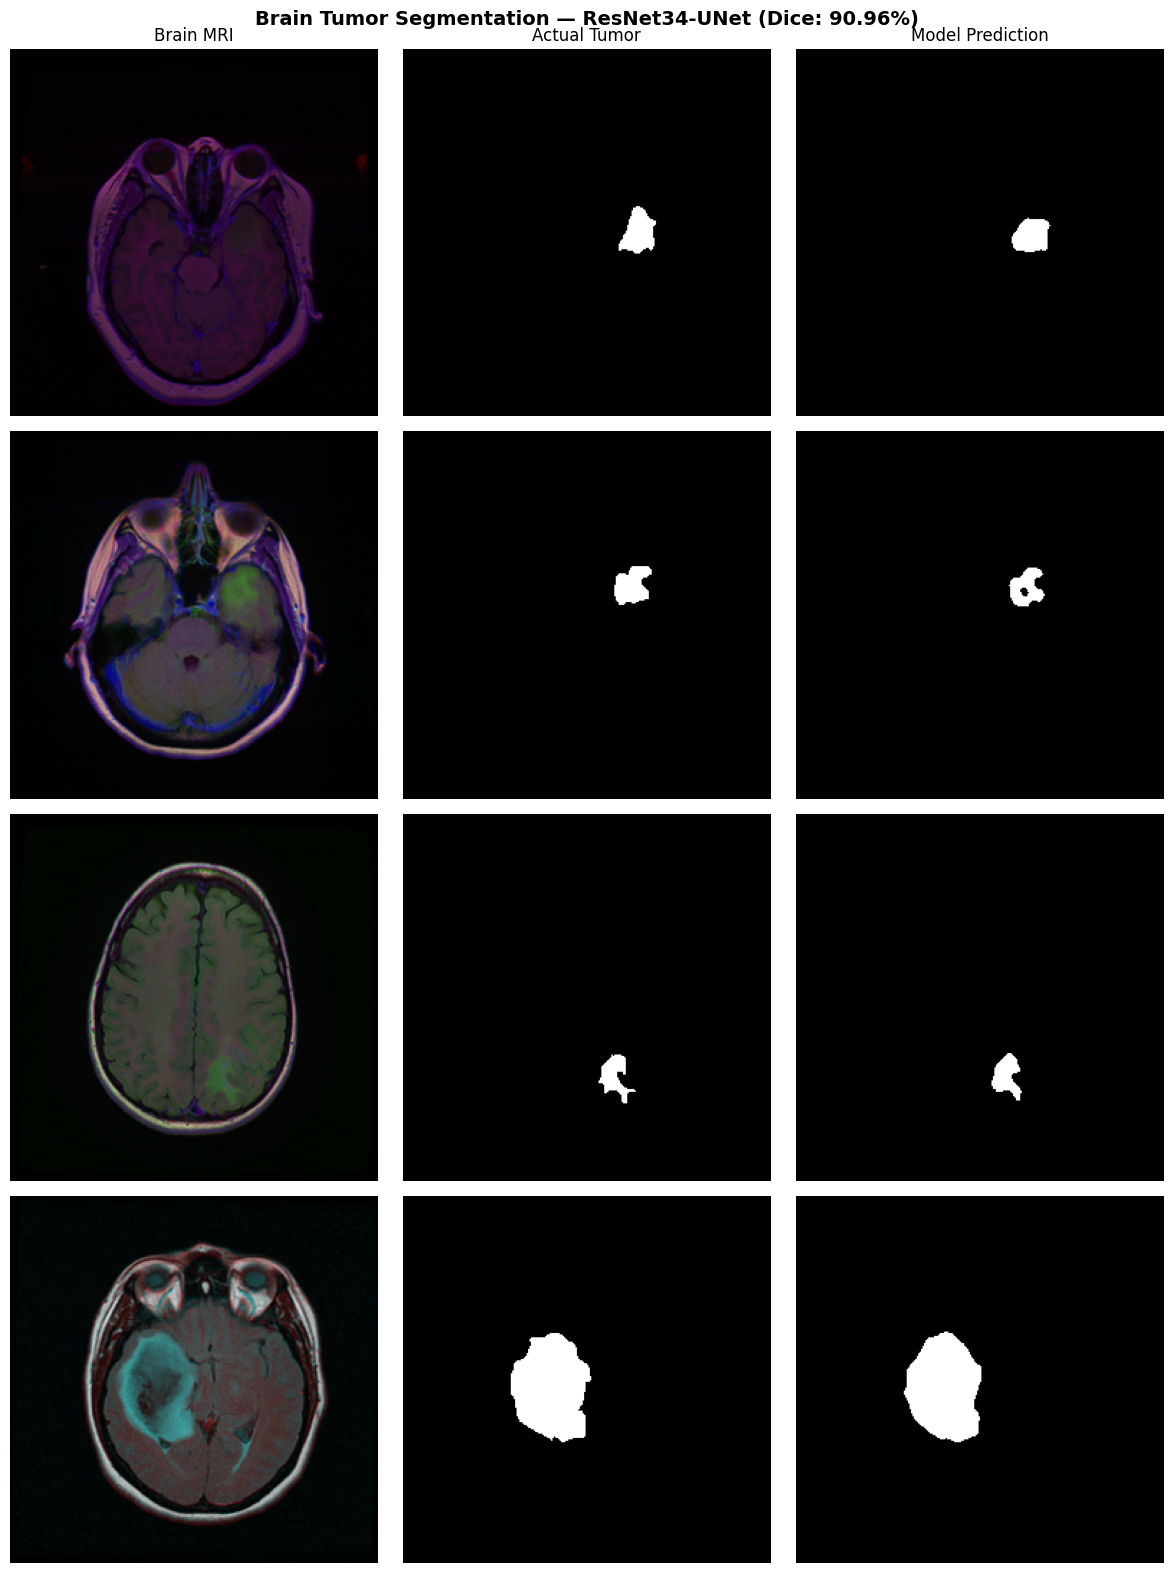

Results saved! ✅


In [20]:
# =====================
# FINAL VISUALIZATION — ACTUAL VS PREDICTED
# =====================

# Best model load karo
model.load_state_dict(torch.load('resnet_unet_best.pth'))
model.eval()

# Tumor wale cases dhundho validation set mein
tumor_samples = []
for imgs, masks in val_loader:
    for i in range(len(imgs)):
        if masks[i].max() > 0:
            tumor_samples.append((imgs[i], masks[i]))
        if len(tumor_samples) >= 4:
            break
    if len(tumor_samples) >= 4:
        break

# Plot karo
fig, axes = plt.subplots(4, 3, figsize=(12, 16))
col_titles = ['Brain MRI', 'Actual Tumor', 'Model Prediction']

for i, (img, mask) in enumerate(tumor_samples):
    img_input = img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        pred = torch.sigmoid(model(img_input))
        pred = (pred > 0.5).float()
    
    # Original image
    img_np = img.permute(1,2,0).numpy()
    axes[i,0].imshow(img_np)
    axes[i,0].set_title(col_titles[0] if i==0 else "")
    axes[i,0].axis('off')
    
    # Actual mask
    axes[i,1].imshow(mask.squeeze(), cmap='gray')
    axes[i,1].set_title(col_titles[1] if i==0 else "")
    axes[i,1].axis('off')
    
    # Predicted mask
    axes[i,2].imshow(pred.squeeze().cpu(), cmap='gray')
    axes[i,2].set_title(col_titles[2] if i==0 else "")
    axes[i,2].axis('off')

plt.suptitle('Brain Tumor Segmentation — ResNet34-UNet (Dice: 90.96%)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Results saved! ✅")

In [21]:
from sklearn.metrics import roc_auc_score
import numpy as np

model.eval()
all_preds  = []
all_masks  = []
all_probs  = []

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs  = imgs.to(device)
        masks = masks.to(device)
        
        probs = torch.sigmoid(model(imgs))  # probability
        preds = (probs > 0.5).float()       # binary prediction
        
        all_probs.append(probs.cpu().numpy().flatten())
        all_preds.append(preds.cpu().numpy().flatten())
        all_masks.append(masks.cpu().numpy().flatten())

all_probs = np.concatenate(all_probs)
all_preds = np.concatenate(all_preds)
all_masks = np.concatenate(all_masks)

# =====================
# METRICS CALCULATE KARO
# =====================

# TP, FP, TN, FN
TP = ((all_preds == 1) & (all_masks == 1)).sum()
FP = ((all_preds == 1) & (all_masks == 0)).sum()
TN = ((all_preds == 0) & (all_masks == 0)).sum()
FN = ((all_preds == 0) & (all_masks == 1)).sum()

# Dice Score
dice = (2*TP) / (2*TP + FP + FN)

# IoU (Jaccard)
iou = TP / (TP + FP + FN)

# Sensitivity (Recall) — tumor kitna pakda
sensitivity = TP / (TP + FN)

# Specificity — healthy tissue kitna sahi pakda
specificity = TN / (TN + FP)

# ROC-AUC
auc = roc_auc_score(all_masks, all_probs)

print(f"Dice Score:  {dice*100:.2f}%")
print(f"IoU:         {iou*100:.2f}%")
print(f"Sensitivity: {sensitivity*100:.2f}%")
print(f"Specificity: {specificity*100:.2f}%")
print(f"ROC-AUC:     {auc*100:.2f}%")

Dice Score:  90.45%
IoU:         82.56%
Sensitivity: 90.28%
Specificity: 99.86%
ROC-AUC:     99.64%
